In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sb
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_binned_cue, plot_rdm
from SensoriMotorPrediction.force import calc_G_force
import PcmPy as pcm
import pingouin as pg

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases



RM-ANOVA for thumb
  Source        SS  DF        MS         F     p-unc      ng2       eps
0    cue  0.004042   4  0.001011  1.123331  0.355642  0.00334  0.832638
1  Error  0.046779  52  0.000900       NaN       NaN      NaN       NaN

RM-ANOVA for index
  Source        SS  DF        MS         F     p-unc      ng2       eps
0    cue  0.046056   4  0.011514  8.315492  0.000029  0.06841  0.472629
1  Error  0.072002  52  0.001385       NaN       NaN      NaN       NaN

RM-ANOVA for middle
  Source        SS  DF        MS         F    p-unc       ng2       eps
0    cue  0.003064   4  0.000766  0.328446  0.85761  0.001431  0.678388
1  Error  0.121275  52  0.002332       NaN      NaN       NaN       NaN

RM-ANOVA for ring
  Source        SS  DF        MS         F     p-unc       ng2       eps
0    cue  0.034885   4  0.008721  6.281116  0.000335  0.033626  0.773713
1  Error  0.072201  52  0.001388       NaN       NaN       NaN       NaN

RM-ANOVA for pinkie
  Source        SS  DF        MS

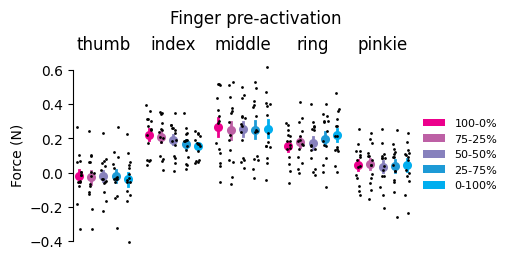

In [2]:
behav = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'behaviour.trial.tsv'), sep='\t')
behav_cue_avg = behav.groupby(['sn', 'cue']).mean(numeric_only=True).reset_index()
fig, axs = plt.subplots(1, 5, sharey=True, figsize=(5, 2.5), constrained_layout=True)
for f, finger in enumerate(gl.fingers):
    ax = axs[f]
    plot_binned_cue(fig, ax, behav_cue_avg, y=f'{finger}0', x='cue', show_individuals=True)
    ax.legend(frameon=False) if f<4 else None
    ax.spines[['left']].set_visible(False)
    ax.tick_params(left=False)
    ax.set_title(finger)
axs[0].tick_params(left=True)
axs[0].spines[['left']].set_visible(True)
axs[0].spines[['left']].set_bounds(-.4, .6)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Finger pre-activation')
fig.savefig(os.path.join('figures', 'preactivation.force.pdf'))
for finger in gl.fingers:
    dv = f'{finger}0'
    aov = pg.rm_anova(
        data=behav_cue_avg,
        dv=dv,
        within='cue',
        subject='sn',
        detailed=True
    )
    print(f'\nRM-ANOVA for {finger}')
    print(aov)
plt.show()

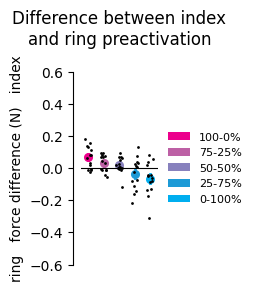

In [3]:
fig, ax = plt.subplots(figsize=(1, 2.5), constrained_layout=True)
plot_binned_cue(fig, ax, behav_cue_avg, y='diff', x='cue', show_individuals=True)
ax.set_ylabel('ring   force difference (N)   index')
ax.set_ylim([-.6, .6])
ax.spines['left'].set_position(('data',-1))
ax.axhline(0, lw=.8, color='k')
ax.set_title('Difference between index\nand ring preactivation', pad=20)
plt.show()

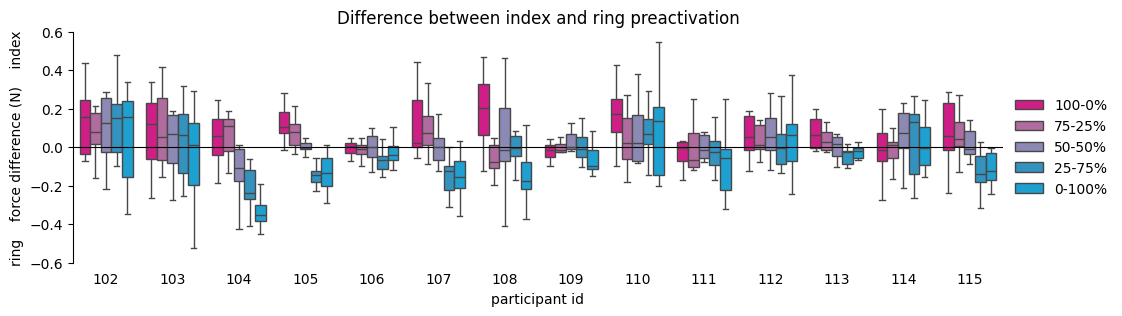

In [4]:
behav_block_cue = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'behaviour.block.cue.tsv'), sep='\t')
fig, ax = plt.subplots(figsize=(12, 3))
sb.boxplot(data=behav_block_cue, ax=ax, x='sn', y='diff', hue='cue', showfliers=False, palette=list(gl.colour_mapping.values())[:5], hue_order=gl.cues)
ax.axhline(0, lw=.8, color='k')
ax.set_ylabel('ring    force difference (N)    index')
ax.set_xlabel('participant id')
ax.set_ylim([-.6, .6])
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.tick_params(bottom=False)
ax.set_title('Difference between index and ring preactivation')
ax.legend(bbox_to_anchor=(1, .5), loc='center left', frameon=False)
plt.show()

force: tval=3.2576122221408705, pval=0.0031180970089363883


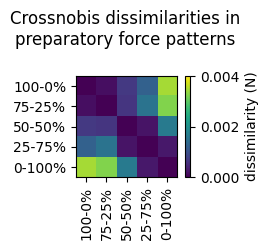

In [5]:
behav_block_cue = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'behaviour.block.cue.tsv'), sep='\t')
G_force, G_force_der = calc_G_force(behav_block_cue, prewhiten=False)
D_force = pcm.G_to_dist(G_force)
vmin, vmax = 0, .004
fig, ax = plt.subplots(figsize=(3, 2.5))
fig, ax = plot_rdm(fig, ax, None, D_force, gl.cues,sqrt=False, source='force', vmin=vmin, vmax=vmax)
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.04)
cbar.set_label('dissimilarity (N)')
fig.suptitle('Crossnobis dissimilarities in\npreparatory force patterns')
fig.tight_layout()
fig.savefig(os.path.join('figures', 'crossnobis.force.pdf'))
plt.show()


RM-ANOVA for thumb
  Source        SS  DF        MS         F     p-unc       ng2       eps
0    cue  0.001458   4  0.000365  0.290632  0.882755  0.000063  0.758938
1  Error  0.065229  52  0.001254       NaN       NaN       NaN       NaN

RM-ANOVA for index
  Source        SS  DF        MS         F     p-unc       ng2       eps
0    cue  0.014000   4  0.003500  2.890998  0.030957  0.001098  0.650096
1  Error  0.062953  52  0.001211       NaN       NaN       NaN       NaN

RM-ANOVA for middle
  Source        SS  DF       MS        F     p-unc      ng2       eps
0    cue  0.000958   4  0.00024  0.14973  0.962302  0.00003  0.847517
1  Error  0.083200  52  0.00160      NaN       NaN      NaN       NaN

RM-ANOVA for ring
  Source        SS  DF        MS         F   p-unc       ng2       eps
0    cue  0.020248   4  0.005062  3.429464  0.0146  0.001346  0.454733
1  Error  0.076753  52  0.001476       NaN     NaN       NaN       NaN

RM-ANOVA for pinkie
  Source        SS  DF        MS      

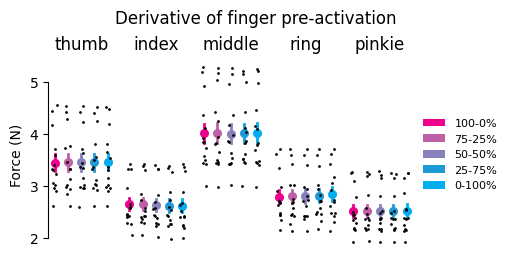

In [6]:
fig, axs = plt.subplots(1, 5, sharey=True, figsize=(5, 2.5), constrained_layout=True)
for f, finger in enumerate(gl.fingers):
    ax = axs[f]
    plot_binned_cue(fig, ax, behav_cue_avg, y=f'{finger}_der0', x='cue', show_individuals=True)
    ax.legend(frameon=False) if f<4 else None
    ax.spines[['left']].set_visible(False)
    ax.tick_params(left=False)
    ax.set_title(finger)
axs[0].tick_params(left=True)
axs[0].spines[['left']].set_visible(True)
axs[0].spines[['left']].set_bounds(2, 5)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Derivative of finger pre-activation')
fig.savefig(os.path.join('figures', 'preactivation.derivative.pdf'))
for finger in gl.fingers:
    dv = f'{finger}_der0'
    aov = pg.rm_anova(
        data=behav_cue_avg,
        dv=dv,
        within='cue',
        subject='sn',
        detailed=True)
    print(f'\nRM-ANOVA for {finger}')
    print(aov)
plt.show()

force: tval=-0.32262402734735257, pval=0.623944996744814


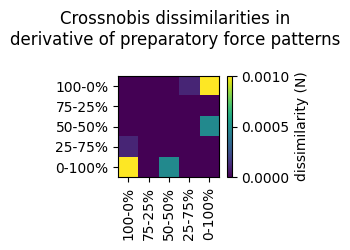

In [7]:
D_force_der = pcm.G_to_dist(G_force_der)
vmin, vmax = 0, .001
fig, ax = plt.subplots(figsize=(3, 2.5))
fig, ax = plot_rdm(fig, ax, None, D_force_der, list(gl.regressor_mapping.keys())[:5],sqrt=False, source='force', vmin=vmin, vmax=vmax)
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.04)
cbar.set_label('dissimilarity (N)')
fig.suptitle('Crossnobis dissimilarities in\nderivative of preparatory force patterns')
fig.tight_layout()
fig.savefig(os.path.join('figures', 'crossnobis.force_derivative.pdf'))
plt.show()

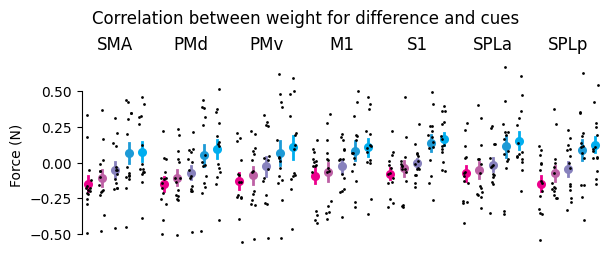

In [32]:
H = 'L'
glm = 12
atlas = 'ROI'
rois = gl.rois[atlas]
preact_weights = pd.read_csv(os.path.join(gl.baseDir, 'smp2', f'glm{glm}', 'preactivation_weights.tsv'), sep='\t')
preact_weights_melt = pd.melt(preact_weights, id_vars=['Hem', 'roi', 'sn'], value_vars=[f'corr_with_{cue}' for cue in gl.cues], value_name='weight', var_name='cue')
preact_weights_melt.cue = preact_weights_melt.cue.map({f'corr_with_{cue}': cue for cue in gl.cues})
preact_weights_melt = preact_weights_melt[preact_weights_melt.Hem==H]
fig, axs = plt.subplots(1, len(rois), sharey=True, figsize=(6, 2.5), constrained_layout=True)
for r, roi in enumerate(rois):
    ax = axs[r]
    plot_binned_cue(fig, ax, preact_weights_melt[preact_weights_melt.roi==roi], y='weight', x='cue', show_individuals=True)
    ax.legend(frameon=False) if r<len(rois) else None
    ax.spines[['left']].set_visible(False)
    ax.tick_params(left=False)
    ax.set_title(roi)
axs[0].tick_params(left=True)
axs[0].spines[['left']].set_visible(True)
axs[0].spines[['left']].set_bounds(-.5, .5)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Correlation between weight for difference and cues')
fig.savefig(os.path.join('figures', 'preactivation.force.pdf'))

plt.show()

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=4.2889545291855535, pval=0.00044056372803719015
PMd: tval=5.0487409468851485, pval=0.00011147130454656168
PMv: tval=3.791242110764398, pval=0.001122184458005319
M1: tval=6.049105154291596, pval=2.0524740853494517e-05
S1: tval=6.896750038939303, pval=5.452825950942718e-06
SPLa: tval=5.251321145918935, pval=7.825201246179327e-05
SPLp: tval=5.218004611519994, pval=8.2908957873477e-05


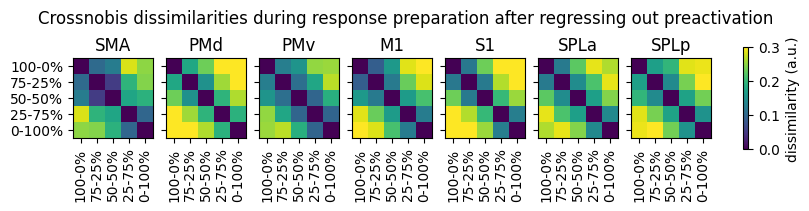

In [18]:

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
vmin, vmax = 0, .3
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.regr_out_preact_ancova.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_rdm(fig, axs, r, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response preparation after regressing out preactivation')
fig.savefig(os.path.join('figures', 'crossnobis.plan.preactivation_out.pdf'))
plt.show()

T  dof alternative     p-val  \
roi  dataset                                                         
M1   original          T-test  2.446785   13     greater  0.014695   
     preactivation out T-test  2.539470   13     greater  0.012340   
PMd  original          T-test  3.697104   13     greater  0.001342   
     preactivation out T-test  2.171093   13     greater  0.024514   
PMv  original          T-test  1.618486   13     greater  0.064776   
     preactivation out T-test  1.660042   13     greater  0.060411   
S1   original          T-test  3.397400   13     greater  0.002383   
     preactivation out T-test  2.890999   13     greater  0.006312   
SMA  original          T-test  1.081856   13     greater  0.149488   
     preactivation out T-test  1.771505   13     greater  0.049951   
SPLa original          T-test  3.034924   13     greater  0.004787   
     preactivation out T-test  2.040903   13     greater  0.031053   
SPLp original          T-test  3.251405   13     greater  0.003156   
     preactivation out T-test  2.070096   13     greater  0.029460   

                                      CI95%   cohen-d    BF10     power  
roi  dataset                                                             
M1   original          T-test   [5.97, inf]  0.653931   4.765  0.749094  
     preactivation out T-test  [23.23, inf]  0.678702   5.473  0.776116  
PMd  original          T-test   [5.15, inf]  0.988093  33.877  0.967881  
     preactivation out T-test  [24.86, inf]  0.580249   3.196  0.659560  
PMv  original          T-test  [-0.12, inf]  0.432559    1.55  0.455756  
     preactivation out T-test  [-4.74, inf]  0.443665   1.629  0.471370  
S1   original          T-test  [34.48, inf]  0.907993  20.947  0.941587  
     preactivation out T-test  [70.84, inf]  0.772652   9.388  0.862330  
SMA  original          T-test  [-0.58, inf]  0.289138   0.886  0.267945  
     preactivation out T-test   [0.03, inf]  0.473455    1.87  0.513396  
SPLa original          T-test   [2.44, inf]  0.811117  11.768  0.890010  
     preactivation out T-test  [15.17, inf]  0.545454   2.667  0.613422  
SPLp original          T-test   [3.25, inf]  0.868974  16.589  0.923736  
     preactivation out T-test  [17.07, inf]  0.553256   2.776  0.623936

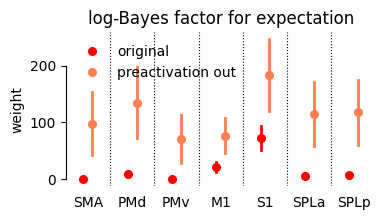

In [10]:
comp_model = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
comp_model = comp_model[(comp_model.epoch=='plan') & (comp_model.glm==glm) & (comp_model.Hem==H)].reset_index()
comp_model['norm_weight'] = np.sqrt(comp_model['weight'] / comp_model['noise'])
comp_model.loc[:, 'dataset'] = comp_model.label.copy() 
comp_model.dataset = comp_model.dataset.replace({None: 'original', 'regr_out_preact_ancova': 'preactivation out'})
comp_model_exp = comp_model[comp_model.component=='expectation']
comp_model_unc = comp_model[comp_model.component=='uncertainty']
sep = [.5, 1.5, 2.5, 3.5, 4.5, 5.5]

fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_exp, x='roi', y='BF', hue='dataset', palette=['red', 'coral'], errorbar='se', linestyles='none', dodge=.2, lw=2)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, 200)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for expectation')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
results = comp_model_exp.groupby(['roi', 'dataset']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)
plt.show()

T  dof alternative     p-val  \
roi  dataset                                                         
M1   original          T-test  1.420972   13     greater  0.089433   
     preactivation out T-test  1.783105   13     greater  0.048960   
PMd  original          T-test  2.108148   13     greater  0.027496   
     preactivation out T-test  2.316324   13     greater  0.018752   
PMv  original          T-test  2.124096   13     greater  0.026710   
     preactivation out T-test  2.397871   13     greater  0.016107   
S1   original          T-test  2.164677   13     greater  0.024804   
     preactivation out T-test  2.762366   13     greater  0.008076   
SMA  original          T-test  1.570233   13     greater  0.070186   
     preactivation out T-test  1.905693   13     greater  0.039522   
SPLa original          T-test  1.675392   13     greater  0.058864   
     preactivation out T-test  1.835956   13     greater  0.044667   
SPLp original          T-test  2.985036   13     greater  0.005269   
     preactivation out T-test  3.109801   13     greater  0.004144   

                                      CI95%   cohen-d    BF10     power  
roi  dataset                                                             
M1   original          T-test  [-0.47, inf]  0.379771   1.238  0.382850  
     preactivation out T-test   [0.02, inf]  0.476555   1.898  0.517769  
PMd  original          T-test   [4.07, inf]  0.563426   2.926  0.637503  
     preactivation out T-test   [6.98, inf]  0.619064   3.934  0.708308  
PMv  original          T-test   [0.56, inf]  0.567689   2.992  0.643139  
     preactivation out T-test   [1.04, inf]  0.640858   4.432  0.734164  
S1   original          T-test   [0.56, inf]  0.578534   3.167  0.657335  
     preactivation out T-test   [1.68, inf]  0.738273   7.688  0.833852  
SMA  original          T-test  [-0.31, inf]  0.419662   1.464  0.437710  
     preactivation out T-test   [0.24, inf]  0.509318   2.224  0.563738  
SPLa original          T-test  [-0.99, inf]  0.447767    1.66  0.477150  
     preactivation out T-test   [0.68, inf]  0.490680   2.031  0.537654  
SPLp original          T-test   [6.47, inf]  0.797784  10.879  0.880908  
     preactivation out T-test    [8.1, inf]  0.831129  13.246  0.902715

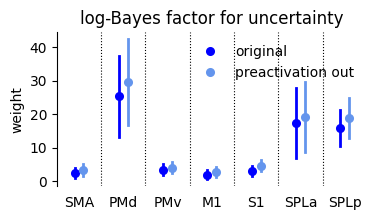

In [17]:
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_unc, x='roi', y='BF', hue='dataset', palette=['blue', 'cornflowerblue'], errorbar='se', linestyles='none', lw=2, dodge=.2)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
axs[0].spines[['left']].set_bounds(0, 30)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for uncertainty')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
results = comp_model_unc.groupby(['roi', 'dataset']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)
plt.show()

,,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
roi,,,,,,,,,,,,
M1,0,dataset,original,preactivation out,True,True,-2.541435,13.0,less,0.012294,5.489,-0.692772
PMd,0,dataset,original,preactivation out,True,True,-2.418514,13.0,less,0.015496,4.57,-0.801325
PMv,0,dataset,original,preactivation out,True,True,-2.289315,13.0,less,0.019716,3.783,-0.810125
S1,0,dataset,original,preactivation out,True,True,-2.402069,13.0,less,0.015980,4.46,-0.627726
SMA,0,dataset,original,preactivation out,True,True,-2.466998,13.0,less,0.014147,4.91,-0.890978
SPLa,0,dataset,original,preactivation out,True,True,-2.506438,13.0,less,0.013134,5.208,-0.877013
SPLp,0,dataset,original,preactivation out,True,True,-2.545167,13.0,less,0.012207,5.52,-0.867245


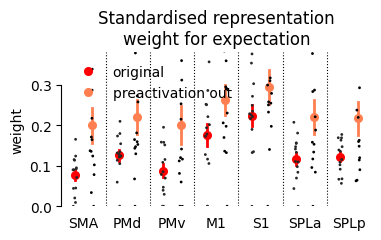

In [12]:
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_exp, x='roi', y='norm_weight', hue='dataset', palette=['red', 'coral'], errorbar='se', linestyles='none', lw=2, dodge=.4)
sb.stripplot(ax=ax, data=comp_model_exp, x='roi', y='norm_weight', hue='dataset', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, .3)
ax.set_ylim(0, .38)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation\nweight for expectation')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
results = comp_model_exp.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='dataset', subject='participant_id', alternative='less'))
display(results)
fig.savefig(os.path.join('figures', 'weight.plan.preact_out.expectation.pdf'))
plt.show()

,,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
roi,,,,,,,,,,,,
M1,0,dataset,original,preactivation out,True,True,-1.638717,13.0,greater,0.937382,0.63,-0.178317
PMd,0,dataset,original,preactivation out,True,True,-2.744983,13.0,greater,0.991651,0.134,-0.170610
PMv,0,dataset,original,preactivation out,True,True,-1.865365,13.0,greater,0.957572,0.474,-0.146025
S1,0,dataset,original,preactivation out,True,True,-1.803689,13.0,greater,0.952754,0.513,-0.199847
SMA,0,dataset,original,preactivation out,True,True,-1.739407,13.0,greater,0.947215,0.557,-0.199456
SPLa,0,dataset,original,preactivation out,True,True,-1.930322,13.0,greater,0.962163,0.435,-0.097429
SPLp,0,dataset,original,preactivation out,True,True,-1.842932,13.0,greater,0.955873,0.488,-0.117383


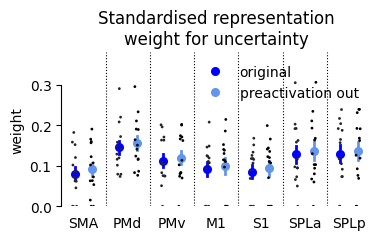

In [13]:
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_unc, x='roi', y='norm_weight', hue='dataset', palette=['blue', 'cornflowerblue'], errorbar='se', linestyles='none', lw=2, dodge=.4)
sb.stripplot(ax=ax, data=comp_model_unc, x='roi', y='norm_weight', hue='dataset', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, .3)
ax.set_ylim(0, .38)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation\nweight for uncertainty')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
results = comp_model_unc.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='dataset', subject='participant_id', alternative='greater'))
display(results)
fig.savefig(os.path.join('figures', 'weight.plan.preact_out.uncertainty.pdf'))
plt.show()

,,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
roi,,,,,,,,,,,,
M1,0,component,expectation,uncertainty,True,True,3.559066,13.0,greater,0.001748,27.143,1.356120
PMd,0,component,expectation,uncertainty,True,True,1.787207,13.0,greater,0.048614,1.908,0.642815
PMv,0,component,expectation,uncertainty,True,True,1.809874,13.0,greater,0.046742,1.964,0.672830
S1,0,component,expectation,uncertainty,True,True,3.836841,13.0,greater,0.001029,42.394,1.477332
SMA,0,component,expectation,uncertainty,True,True,2.112513,13.0,greater,0.027279,2.944,0.816146
SPLa,0,component,expectation,uncertainty,True,True,1.796772,13.0,greater,0.047816,1.931,0.685854
SPLp,0,component,expectation,uncertainty,True,True,1.734757,13.0,greater,0.053207,1.786,0.651314


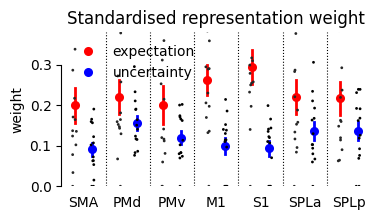

In [14]:
comp_model_regr_out = comp_model[comp_model.dataset=='preactivation out']
fig, ax = plt.subplots(figsize=(4, 2))
sb.pointplot(ax=ax, data=comp_model_regr_out, x='roi', y='norm_weight', hue='component', palette=['red', 'blue'], errorbar='se', linestyles='none', lw=2, dodge=.4)
sb.stripplot(ax=ax, data=comp_model_regr_out, x='roi', y='norm_weight', hue='component', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, .3)
ax.set_ylim(0, .38)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
results = comp_model_regr_out.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id', alternative='greater'))
display(results)
fig.savefig(os.path.join('figures', 'weight.plan.preact_out.pdf'))
plt.show()

T  dof alternative     p-val         CI95%  \
roi  group                                                             
M1   False T-test  1.785623    6     greater  0.062202  [-2.62, inf]   
     True  T-test  2.141098    6     greater  0.038017   [1.25, inf]   
PMd  False T-test  1.895705    6     greater  0.053402  [-0.17, inf]   
     True  T-test  3.361658    6     greater  0.007599   [5.51, inf]   
PMv  False T-test  0.652314    6     greater  0.269186  [-1.23, inf]   
     True  T-test  1.507184    6     greater  0.091242  [-0.56, inf]   
S1   False T-test  2.815116    6     greater  0.015275  [17.24, inf]   
     True  T-test  2.307148    6     greater  0.030252  [13.94, inf]   
SMA  False T-test  0.676712    6     greater  0.261903  [-2.07, inf]   
     True  T-test  1.102232    6     greater  0.156300  [-0.56, inf]   
SPLa False T-test  1.484135    6     greater  0.094152  [-1.49, inf]   
     True  T-test  3.016643    6     greater  0.011749   [2.45, inf]   
SPLp False T-test  1.540271    6     greater  0.087212  [-1.06, inf]   
     True  T-test  3.111427    6     greater  0.010405   [3.84, inf]   

                    cohen-d   BF10     power  
roi  group                                    
M1   False T-test  0.674902  2.059  0.474882  
     True  T-test  0.809259  2.921  0.598068  
PMd  False T-test  0.716509  2.291  0.513378  
     True  T-test  1.270587  9.734  0.904694  
PMv  False T-test  0.246551  0.841  0.143778  
     True  T-test  0.569662  1.585  0.379156  
S1   False T-test  1.064014   5.73  0.798298  
     True  T-test  0.872020   3.45  0.652985  
SMA  False T-test  0.255773  0.851  0.148744  
     True  T-test  0.416604  1.126  0.253069  
SPLa False T-test  0.560950  1.552  0.371461  
     True  T-test  1.140184  6.985  0.843836  
SPLp False T-test  0.582168  1.634  0.390282  
     True  T-test  1.176009  7.659  0.862679

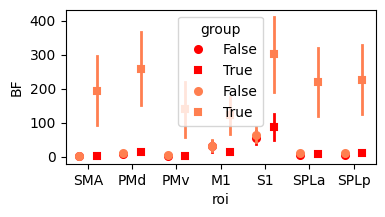

In [15]:
behav_100_avg = behav[behav.cue.isin(['100-0%', '0-100%'])].groupby(['sn',]).mean(numeric_only=True).reset_index()
forceDiff_median = behav_100_avg.forceDiff.median()
behav_100_avg['group'] = behav_100_avg.forceDiff > forceDiff_median
#behav_100_avg.group = behav_100_avg.group.map({True: 'high pre-activation', False: 'low pre-activation'})
comp_model_exp['sn'] = comp_model_exp.participant_id
comp_model_exp_g = comp_model_exp.merge(behav_100_avg[['sn', 'group']], on='sn',)
comp_model_exp_g = comp_model_exp_g[['participant_id', 'roi', 'norm_weight', 'BF', 'group', 'weight', 'dataset']]

fig, ax = plt.subplots(figsize=(4, 2))

sb.pointplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='original'], x='roi', y='BF', 
    hue='group', palette=['r', 'r'], markers=['o', 's'], errorbar='se', linestyles='none', lw=2, dodge=.4, hue_order=[False, True])
sb.pointplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='preactivation out'], x='roi', y='BF', 
    hue='group', palette=['coral', 'coral'], markers=['o', 's'], errorbar='se', linestyles='none', lw=2, dodge=.4, hue_order=[False, True])

results = comp_model_exp_g[comp_model_exp_g.dataset=='original'].groupby(['roi', 'group']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)

plt.show()

T  dof alternative     p-val  \
roi  dataset                                                         
M1   original          T-test -0.868777   12     greater  0.798995   
     preactivation out T-test  1.532804   12     greater  0.075627   
PMd  original          T-test  0.926596   12     greater  0.186199   
     preactivation out T-test  2.860974   12     greater  0.007164   
PMv  original          T-test  0.809807   12     greater  0.216908   
     preactivation out T-test  2.612984   12     greater  0.011338   
S1   original          T-test  0.439773   12     greater  0.333959   
     preactivation out T-test  2.227967   12     greater  0.022889   
SMA  original          T-test  0.130792   12     greater  0.449053   
     preactivation out T-test  2.714534   12     greater  0.009399   
SPLa original          T-test  0.667681   12     greater  0.258486   
     preactivation out T-test  2.926585   12     greater  0.006342   
SPLp original          T-test  1.607828   12     greater  0.066925   
     preactivation out T-test  3.117275   12     greater  0.004450   

                                      CI95%   cohen-d    BF10     power  
roi  dataset                                                             
M1   original          T-test  [-0.06, inf]  0.464381   0.877  0.006812  
     preactivation out T-test  [-0.01, inf]  0.819318   1.853  0.421181  
PMd  original          T-test  [-0.01, inf]  0.495286   1.179  0.220636  
     preactivation out T-test   [0.04, inf]  1.529255   8.131  0.852995  
PMv  original          T-test  [-0.01, inf]  0.432860   1.105  0.189378  
     preactivation out T-test   [0.03, inf]  1.396699   5.957  0.792930  
S1   original          T-test  [-0.04, inf]  0.235069   0.951  0.109462  
     preactivation out T-test   [0.02, inf]  1.190898   3.772  0.675443  
SMA  original          T-test  [-0.01, inf]  0.069911   0.897  0.064099  
     preactivation out T-test   [0.04, inf]  1.450980   6.757  0.819103  
SPLa original          T-test  [-0.01, inf]  0.356890   1.033  0.155226  
     preactivation out T-test   [0.04, inf]  1.564326   8.844  0.866698  
SPLp original          T-test   [-0.0, inf]  0.859420   1.983  0.448976  
     preactivation out T-test   [0.05, inf]  1.666254  11.332  0.901431

,,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
roi,,,,,,,,,
M1,T-test,-3.014747,6,greater,0.988222,"[-0.13, inf]",1.343359,0.143,5.309319e-07
PMd,T-test,-2.776243,6,greater,0.983922,"[-0.19, inf]",1.383381,0.181,3.215603e-07
PMv,T-test,-2.608880,6,greater,0.979910,"[-0.18, inf]",1.376527,0.214,3.506345e-07
S1,T-test,-2.682062,6,greater,0.981782,"[-0.16, inf]",1.087082,0.199,1.047910e-05
SMA,T-test,-2.877324,6,greater,0.985922,"[-0.19, inf]",1.527268,0.164,4.890414e-08
SPLa,T-test,-2.915734,6,greater,0.986610,"[-0.17, inf]",1.544864,0.158,3.850783e-08
SPLp,T-test,-3.002923,6,greater,0.988041,"[-0.17, inf]",1.569236,0.145,2.756887e-08


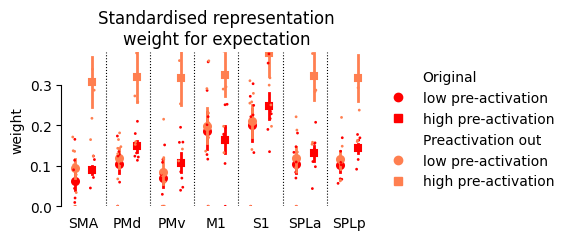

In [16]:
fig, ax = plt.subplots(figsize=(4, 2))

sb.pointplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='original'], x='roi', y='norm_weight', 
    hue='group', palette=['r', 'r'], markers=['o', 's'], errorbar='se', linestyles='none', lw=2, dodge=.4, hue_order=[False, True])
sb.pointplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='preactivation out'], x='roi', y='norm_weight', 
    hue='group', palette=['coral', 'coral'], markers=['o', 's'], errorbar='se', linestyles='none', lw=2, dodge=.4, hue_order=[False, True])
sb.stripplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='original'], x='roi', y='norm_weight', 
    hue='group', size=2, palette=['r', 'r'], jitter=.1, dodge=True, legend=False, hue_order=[False, True])
sb.stripplot(ax=ax, data=comp_model_exp_g[comp_model_exp_g.dataset=='preactivation out'], x='roi', y='norm_weight', 
    hue='group', size=2, palette=['coral', 'coral'], jitter=.1, dodge=True, legend=False, hue_order=[False, True])
    
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines[['left']].set_bounds(0, .3)
ax.set_ylim(0, .38)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation\nweight for expectation')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')

handles = [
    Line2D([], [], linestyle='none', label='Original'),
    Line2D([0], [0], marker='o', color='r', linestyle='none', label='low pre-activation'),
    Line2D([0], [0], marker='s', color='r', linestyle='none', label='high pre-activation'),
    
    Line2D([], [], linestyle='none', label='Preactivation out'),
    Line2D([0], [0], marker='o', color='coral', linestyle='none', label='low pre-activation'),
    Line2D([0], [0], marker='s', color='coral', linestyle='none', label='high pre-activation'),
]

ax.legend(handles=handles, frameon=False, loc='center left', bbox_to_anchor=(1, .5))

fig.savefig(os.path.join('figures', 'weight.plan.preact_out_vs_original.expectation.pdf'))

ttest_ind = comp_model_exp_g.groupby(['roi', 'dataset']).apply(
    lambda g: pg.ttest(g.loc[g['group'], 'weight'], g.loc[~g['group'], 'weight'], alternative='greater'))

display(ttest_ind)

ttest_dep = comp_model_exp_g[comp_model_exp_g['group'] == True].groupby('roi').apply(lambda g: pg.ttest(
        g.loc[g['dataset'] == 'original'].sort_values('participant_id')['weight'].values,
        g.loc[g['dataset'] == 'preactivation out'].sort_values('participant_id')['weight'].values,
        paired=True,
        alternative='greater'
    ))

display(ttest_dep)

plt.show()